# TASK 1 : PREPARING

### 1.1 -- Importing dataset

In [84]:
import numpy as np
import pandas as pd

# 1.1 -- Importing dataset
df = pd.read_csv("../data/synthetic_coffee_health_10000.csv")
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


### 1.2 -- Basic preparing of the dataset

In [85]:
# Removing empty data

df.isna().sum()

ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64

In [86]:
for col in df.columns:
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_val = df[col].mode()
            if not mode_val.empty:
                df[col] = df[col].fillna(mode_val[0])

In [87]:
# Dataset types formatting

df.dtypes

ID                           int64
Age                          int64
Gender                         str
Country                        str
Coffee_Intake              float64
Caffeine_mg                float64
Sleep_Hours                float64
Sleep_Quality                  str
BMI                        float64
Heart_Rate                   int64
Stress_Level                   str
Physical_Activity_Hours    float64
Health_Issues                  str
Occupation                     str
Smoking                      int64
Alcohol_Consumption          int64
dtype: object

In [88]:
cols = ["Smoking", "Alcohol_Consumption"]
df[cols] = df[cols].astype(bool)
# we can skip loop for logical data type transform
# as boolean is correctly interpret from numeric 0 & 1
df.dtypes

ID                           int64
Age                          int64
Gender                         str
Country                        str
Coffee_Intake              float64
Caffeine_mg                float64
Sleep_Hours                float64
Sleep_Quality                  str
BMI                        float64
Heart_Rate                   int64
Stress_Level                   str
Physical_Activity_Hours    float64
Health_Issues                  str
Occupation                     str
Smoking                       bool
Alcohol_Consumption           bool
dtype: object

In [89]:
 # preview altered table
df

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Mild,Other,False,False
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Mild,Service,False,False
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,False,False
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,False,False
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,False,True
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,False,False
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,Mild,Student,True,True
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,Mild,Student,False,False


In [90]:
# Cleaning data from extreme values

df = df[
    (df["Age"].between(12, 130)) &
    (df["Heart_Rate"].between(40, 180)) &
    (df["Sleep_Hours"] < 24) &
    (df["BMI"].between(12, 60)) &
    (df["Caffeine_mg"] < 1200) # dangerous caffeine dose per day
]
df.shape[0] # shows 10000 -> all data was by default "clean"

10000

# TASK 2 : VISUAL DATA ANALYSIS

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
sns.set_theme(style="whitegrid")

### 2.1 -- One variable distribution

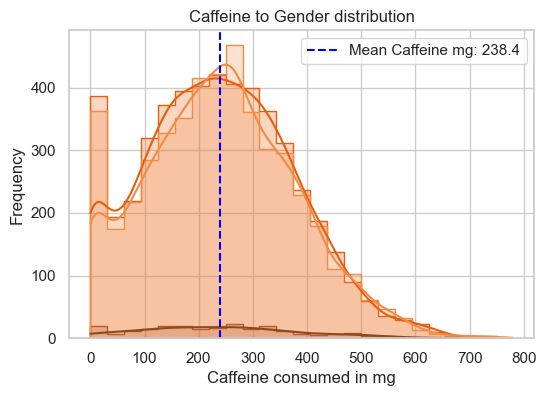

In [93]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Caffeine_mg", hue="Gender", kde=True, bins=25, palette="Oranges_d", element="step")
plt.axvline(df["Caffeine_mg"].mean(), color="blue", linestyle="--",
            label=f"Mean Caffeine mg: {df['Caffeine_mg'].mean():.1f}")
plt.title("Caffeine to Gender distribution")
plt.xlabel("Caffeine consumed in mg")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [94]:
df["Gender"].value_counts()

Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64

_As we can see from the histogram there is almost no difference in caffeine consumption between Males & Females. In this plot we can also see the number of participants who has chosen the non-binary variant to observe their caffeine consumption which in general repeats the binary ones with its curve. The mode of the caffeine consumed is reaches inbetween 200 and 300, being closer to the 200 value and is marked by the red dashed line_

p### 2.2 -- Categories comparison

In [95]:
df["Health_Issues"].value_counts()

Health_Issues
Mild        9520
Moderate     463
Severe        17
Name: count, dtype: int64

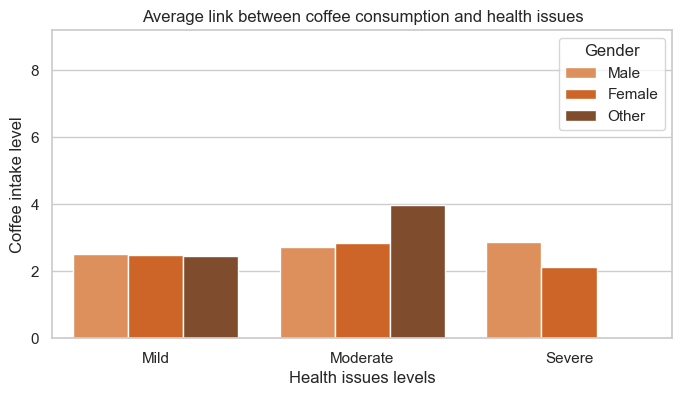

In [96]:
plt.figure(figsize=(8,4))
order = df["Health_Issues"].unique()

ax = sns.barplot(data=df, x="Health_Issues", y="Coffee_Intake", hue="Gender", order=order, palette="Oranges_d", errorbar=None)
plt.ylim(0, df["Coffee_Intake"].max() + 1) # better visual difference
plt.title("Average link between coffee consumption and health issues")
plt.xlabel("Health issues levels")
plt.ylabel("Coffee intake level")
plt.show()

_As we can see from this plot the average level of coffee consumed is quite the same for each level of health issues so that means there is nearly no effect of the consumed coffee to the illness development. There is the minor difference for the severe level that Males have around 3.0 coffee income (~300 mg) when Females have the 2.0 level. There is a minor increase in the moderate level where non-binary people take leadership and are 2 levels of the coffee consumed ahead (Binary ~ 2.0 , Non-binary > 4.0)_

### 2.3 -- Dispersion and emission analysis

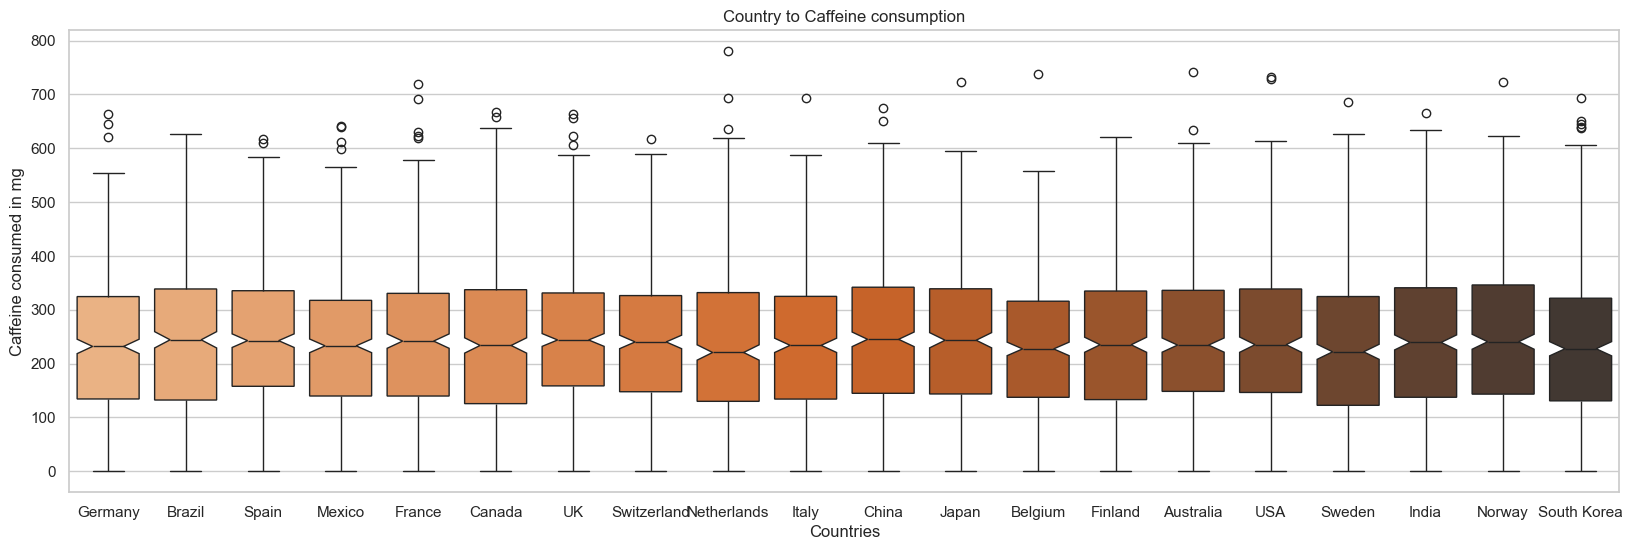

In [104]:
plt.figure(figsize=(20,6))
order = df["Country"].unique()

sns.boxplot(data=df, x="Country", y="Caffeine_mg", hue="Country", order=order, palette="Oranges_d", notch=True)
plt.title("Country to Caffeine consumption")
plt.xlabel("Countries")
plt.ylabel("Caffeine consumed in mg")
plt.show()

_The average median of the caffeine consumed is approximately the same in every country and is equal to he 200-250 mg with the least in the South Korea. Judging from the different height of the box in Canada and Netherland for example displays the differance in caffeine consumption habits. Also we can see some extreme exceptional cases being displayed as circles at the top of the graph_

### 2.4 -- Structure and proportions

In [110]:
occupation_counts = df["Occupation"].value_counts()
occupation_counts

Occupation
Office        2073
Other         2038
Student       1968
Healthcare    1964
Service       1957
Name: count, dtype: int64

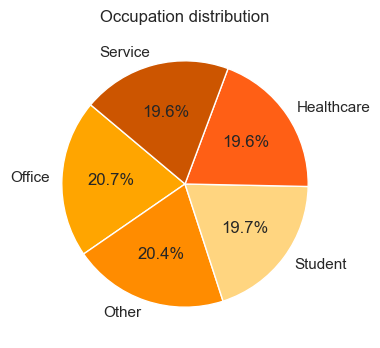

In [109]:
plt.figure(figsize=(4,4))
plt.pie(occupation_counts, labels=occupation_counts.index, autopct="%1.1f%%", startangle=140, colors=["#FFA500", "#FF8C00", "#FFD580", "#FF5F15", "#CC5500"])
plt.title("Occupation distribution")
plt.show()

_As we can see from the pie diagram the distribution between participants' occupation is nearly even and are following: Student, Office worker, Service worker, Healthcare and minority of other (which can be taken as mode and would not change the distribution proportion)_

## 2.5 -- Two Numeric values connection

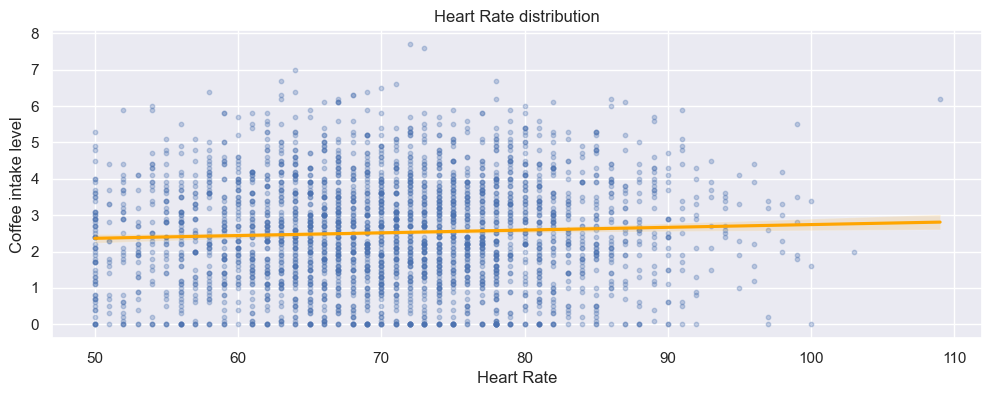

In [121]:
plt.figure(figsize=(12,4))
sns.regplot(data=df.sample(3000), x="Heart_Rate", y="Coffee_Intake", scatter_kws={'alpha':0.3, 's': 10}, line_kws={'color':'orange'})
plt.title("Heart Rate distribution")
plt.xlabel("Heart Rate")
plt.ylabel("Coffee intake level")
plt.show()

_As we can see that the there is a tendency to have a higher heart rate in case of higher coffee intake. The vast majority of the participants have the approximately 60-80 heart beat in average and quite a high concentration around the value of 50 which might be the reason of the high coffee consumption_

### 2.6 -- Trends OR Dynamics

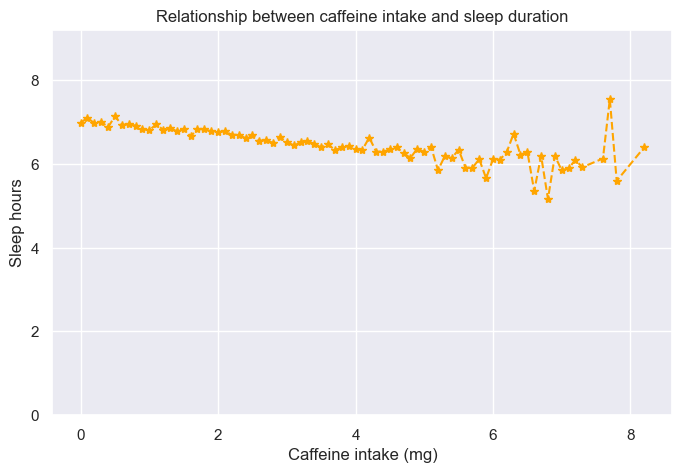

In [131]:
plt.figure(figsize=(8,5))
trend_data = df.groupby("Coffee_Intake")["Sleep_Hours"].mean().sort_index()

plt.plot(trend_data.index, trend_data.values, marker='*', linestyle='--', color='orange')
plt.ylim(0, df["Coffee_Intake"].max() + 1) # better visual difference
plt.xlabel("Caffeine intake (mg)")
plt.ylabel("Sleep hours")
plt.title("Relationship between caffeine intake and sleep duration")
plt.show()

In [132]:
trend_data

Coffee_Intake
0.0    6.986201
0.1    7.106250
0.2    6.976543
0.3    7.017045
0.4    6.882353
         ...   
7.3    5.925000
7.6    6.133333
7.7    7.550000
7.8    5.600000
8.2    6.400000
Name: Sleep_Hours, Length: 78, dtype: float64

_We can observe a weak negative trend between coffee consumption and sleep duration. With increasing coffee consumption, average sleep duration gradually decreases. However, the fluctuations in the values indicate that the dependence is not strong and that other factors may influence sleep._

### 2.7 -- Correlation matrix

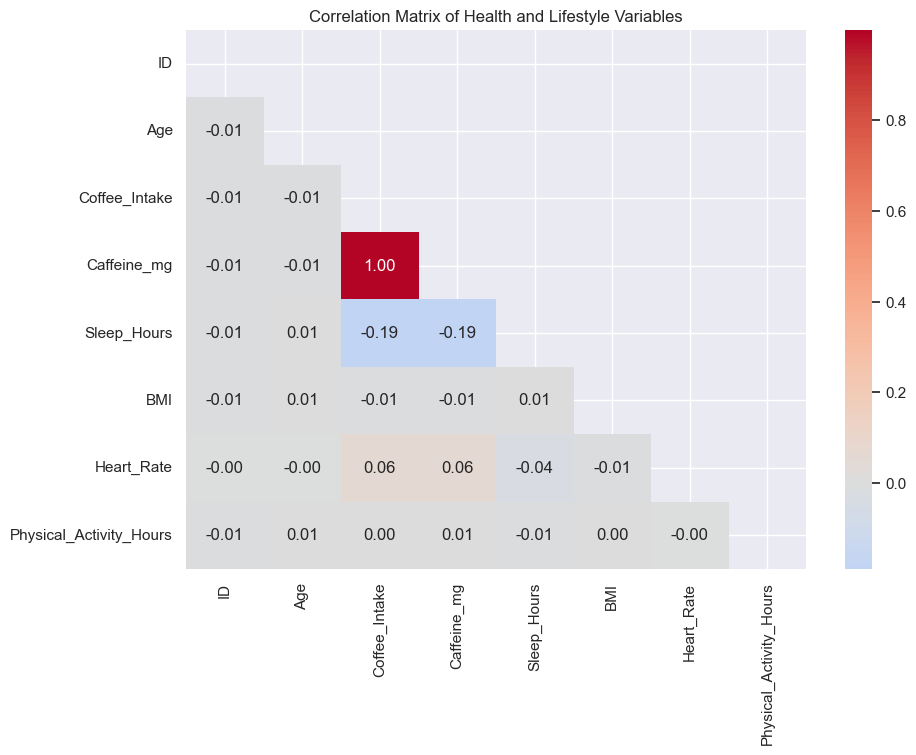

In [133]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap( corr_matrix, mask=mask, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Health and Lifestyle Variables")
plt.show()

_This matrix show us the correlation level, as we can observe the dependence in between columns is nearly absent. There is a little correlation in terms of consumed coffe (Coffee_Intake, Caffeine_mg) and the sleep hours, this dependence we have seen before on previous graphs. The strongest one (absolute one) os between Coffee_Intake and Caffeine_mg as they rate the dame thig_

### 2.8 --Combined graph

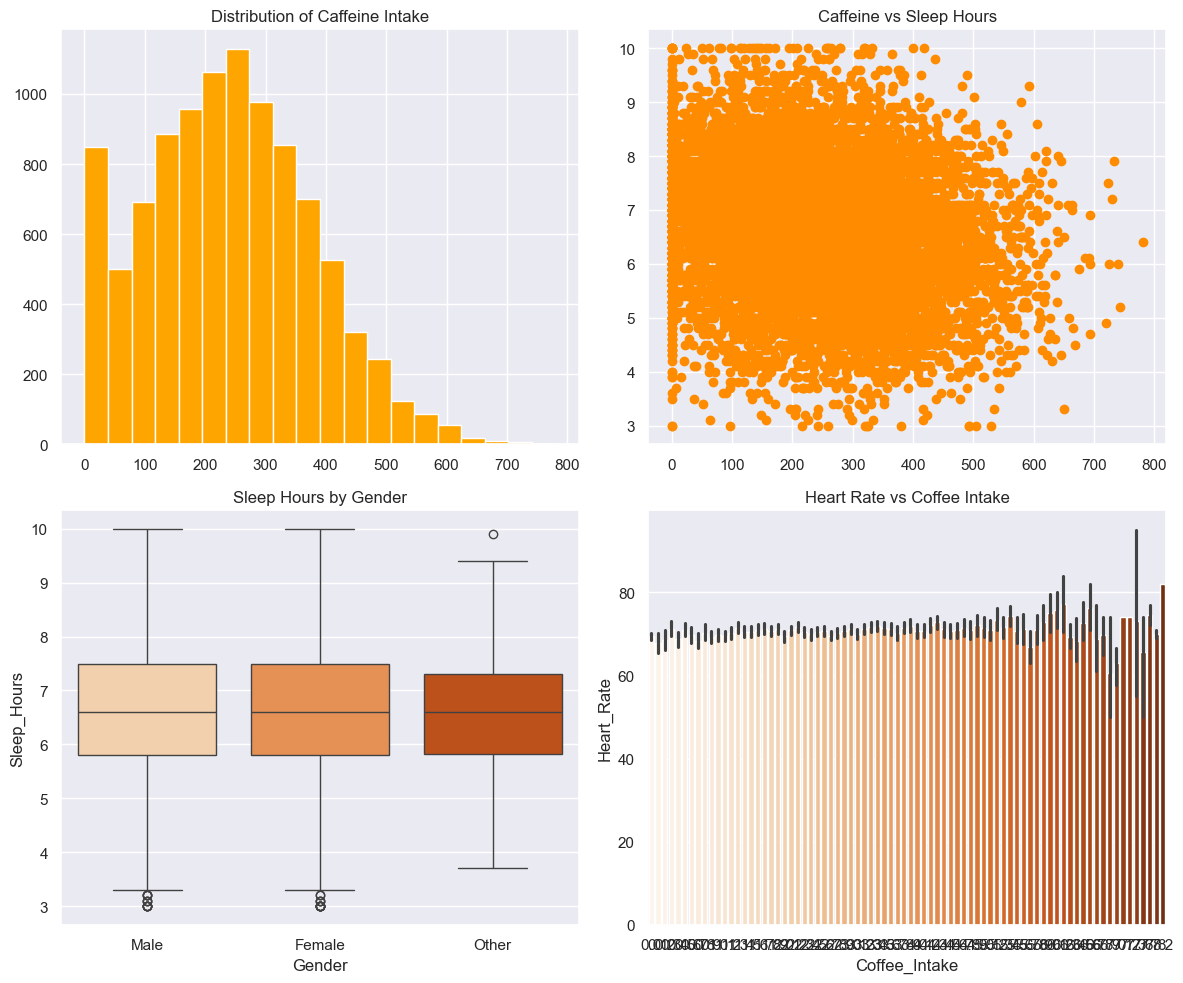

In [144]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))

# Histogram
axs[0,0].hist(df["Caffeine_mg"], bins=20, color='orange',)
axs[0,0].set_title("Distribution of Caffeine Intake")

# Scatter plot
axs[0,1].scatter(df["Caffeine_mg"], df["Sleep_Hours"], color='darkorange')
axs[0,1].set_title("Caffeine vs Sleep Hours")

# Boxplot
sns.boxplot(x="Gender", y="Sleep_Hours", hue="Gender", legend=False, data=df, ax=axs[1,0], palette="Oranges")
axs[1,0].set_title("Sleep Hours by Gender")

# Barplot
sns.barplot(x="Coffee_Intake", y="Heart_Rate", hue="Coffee_Intake", legend=False, data=df, ax=axs[1,1], palette="Oranges")
axs[1,1].set_title("Heart Rate vs Coffee Intake")

plt.tight_layout()
plt.show()

_The panel graphs show that most people consume moderate amounts of caffeine, and there is a weak negative relationship between caffeine levels and sleep duration. However, sleep duration is almost the same between the sexes, and the relationship between coffee consumption and heart rate is weak._